In [1]:
import tensorflow as tf
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import RMSprop
from keras import backend as K

I0000 00:00:1780912034.674642   48512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780912034.688594   48512 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780912038.125580   48512 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780912044.267749   48512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# Reshape input data to include the channel dimension
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

In [4]:
# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [5]:
# Define the model architecture
def build_model(optimizer):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    return model

In [6]:
# Training with different optimisers
optimizers = ['Adagrad', 'Adadelta', 'SGD', 'RMSprop', 'Adam']
history_dict = {}

for opt in optimizers:
    print(f'Training with {opt} optimizer...')
    model = build_model(opt)
    history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), verbose=1)
    history_dict[opt] = history.history

Training with Adagrad optimizer...


/workspaces/COM7019_AI-NN/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1780912593.390440   48512 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.5307 - loss: 1.6638 - val_accuracy: 0.8408 - val_loss: 0.8242
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.7848 - loss: 0.7648 - val_accuracy: 0.8805 - val_loss: 0.4828
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.8289 - loss: 0.5833 - val_accuracy: 0.8954 - val_loss: 0.3938
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.8525 - loss: 0.5011 - val_accuracy: 0.9053 - val_loss: 0.3504
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8648 - loss: 0.4560 - val_accuracy: 0.9126 - val_loss: 0.3223
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.8724 - loss: 0.4266 - val_accuracy: 0.9178 - val_loss: 0.3020
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.8791 - loss: 0.4057 - val_accuracy: 0.9203 - val_loss: 0.2873
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.8843 - loss: 0.3894 - 

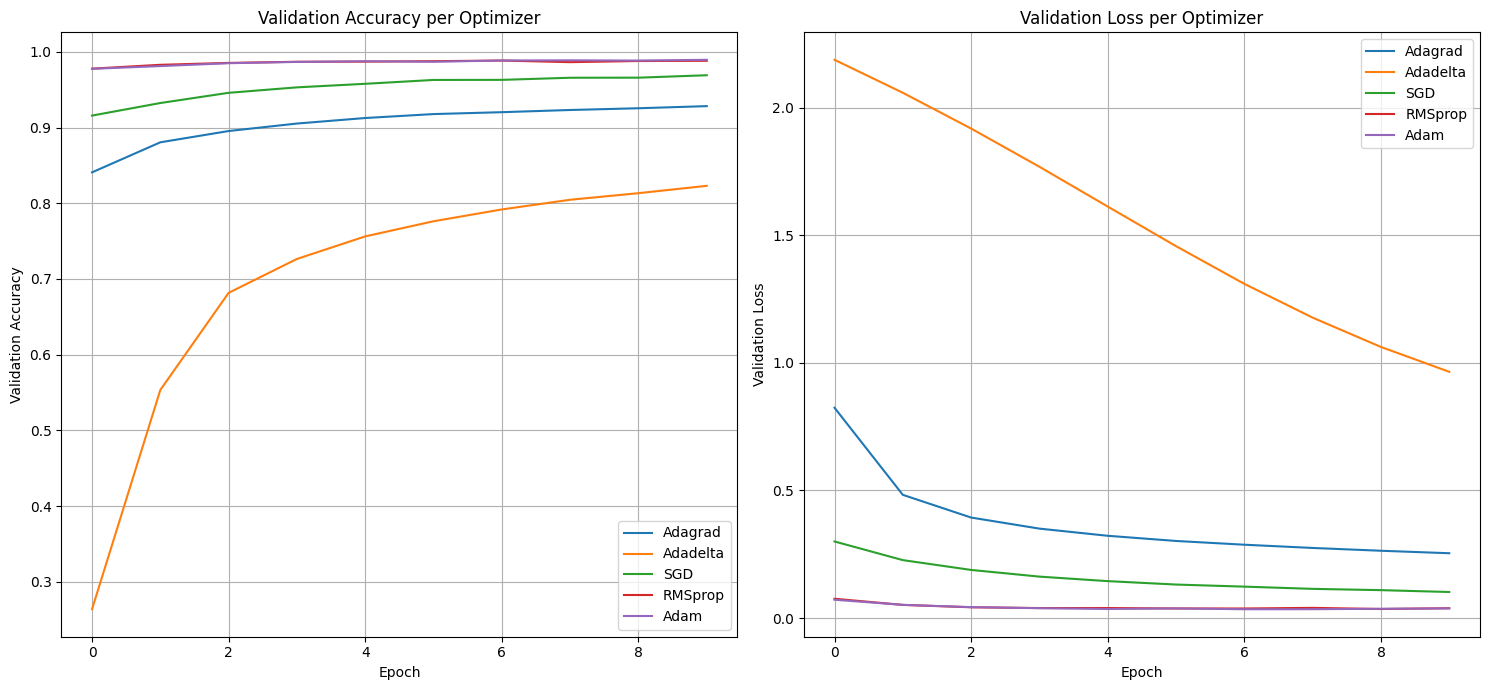

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# Subplot 1: Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
for opt in optimizers:
    plt.plot(history_dict[opt]['val_accuracy'], label=f'{opt}')
plt.title('Validation Accuracy per Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Subplot 2: Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
for opt in optimizers:
    plt.plot(history_dict[opt]['val_loss'], label=f'{opt}')
plt.title('Validation Loss per Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()